In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

import torch
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Для новых Mac на чипах M1/M2/M3
else:
    device = torch.device("cpu")

print(f"Вычисления будут производиться на: {device}")

##### Unload data

In [ ]:
# Select file
from lab2.

file  = pd.read_csv("4.dat", sep="\t")
# file = pd.read_csv("5.dat", sep="\t")
# file = pd.read_csv("6.dat", sep="\t")

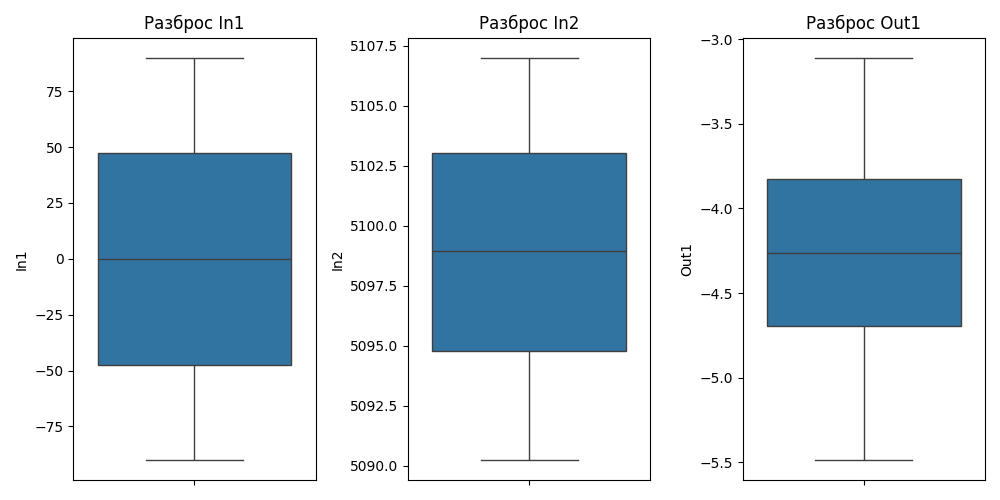

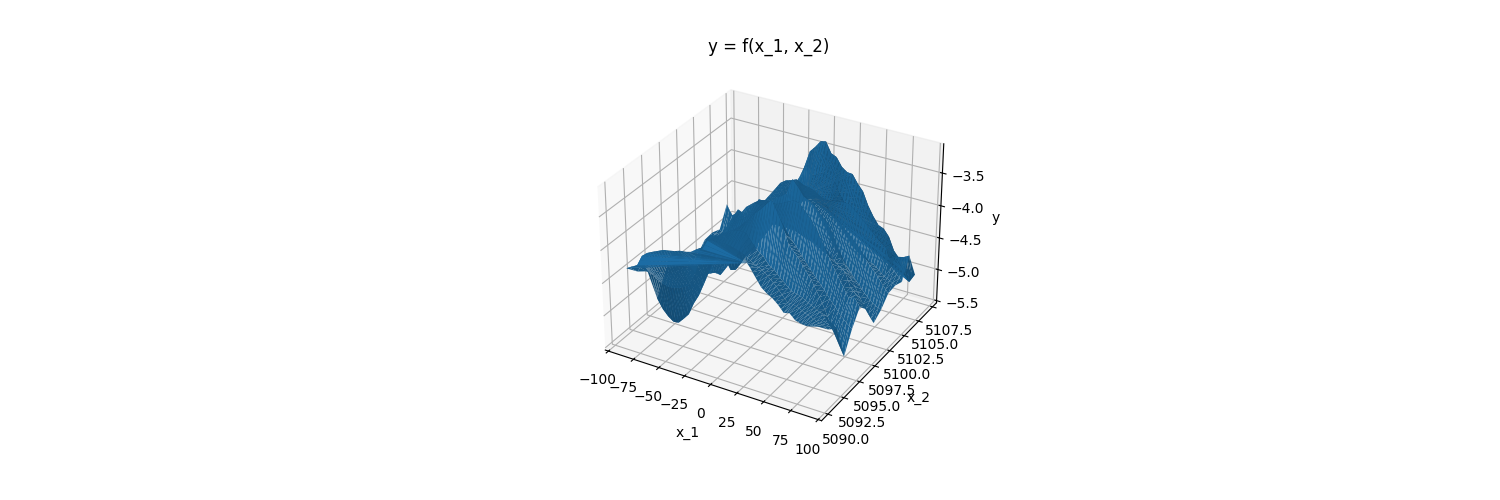

In [ ]:
# Visualization
fig1  = plt.figure( figsize=( 15, 5 ) )
ax    = fig1.add_subplot( projection="3d" )

ax.plot_trisurf( file['In1'], file['In2'], file['Out1'] )
ax.set_xlabel("x_1")
ax.set_ylabel("x_2")
ax.set_zlabel("y")
ax.set_title("y = f(x_1, x_2)")


fig2     = plt.figure( figsize=( 10, 5 ) )
for i, col in enumerate(['In1', 'In2', 'Out1']):
   fig2.add_subplot( 1, 3, i+1 )
   sns.boxplot( data=file, y=col )
   plt.title(f'Разброс {col}')
plt.tight_layout()


plt.show()

In [ ]:
file.describe()

##### Preprocessing

In [6]:
ss_x = StandardScaler()
X_ss = ss_x.fit_transform(file[["In1", 'In2']])

ss_y = StandardScaler()
Y_ss = ss_y.fit_transform(file[["Out1"]])

# Prepare PyTorch dataset from preprocessing data
X_tensor    = torch.tensor( X_ss, dtype=torch.float32 )
Y_tensor    = torch.tensor( Y_ss, dtype=torch.float32 )
dataset     = TensorDataset( X_tensor, Y_tensor )

train_loader = DataLoader(dataset, batch_size=128, shuffle=True)

# Разделение датасета
# total_size = len(dataset)
# train_size = int(0.9 * total_size)
# val_size   = total_size - train_size # Вычитание гарантирует, что мы не потеряем элементы из-за округления

# train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)

##### Optimization methods

In [43]:
# Using PyTorch
# train_dataset = TensorDataset( X_tensor, Y_tensor )

class MyModel( nn.Module ):
   
    def __init__( self ):
        super( MyModel, self ).__init__()
        
        self.net = nn.Sequential(
            nn.Linear( 2, 256 ), 
            nn.ReLU(),
                                    
            nn.Linear( 256, 512 ),
            # nn.BatchNorm1d( 64 ),
            nn.ReLU(),
            # nn.Dropout( p = 0.1 ),
            
            nn.Linear( 512, 512 ),
			# nn.BatchNorm1d( 256 ),
            nn.ReLU(),
            # nn.Dropout( p = 0.1 ),
            
			nn.Linear( 512, 256 ),
            nn.ReLU(),
            
            nn.Linear( 256, 128 ),
            nn.ReLU(),
                        
            nn.Linear( 128, 1 )
        )
              
        # for m in self.modules():
        #     if isinstance( m, nn.Linear ):
        #         nn.init.xavier_normal_( m.weight )
        #         if m.bias is not None:
        #             nn.init.constant_( m.bias, 0 )

    def forward( self, x ):
        return self.net( x ) # + self.net( x )


model = MyModel()
model.to(device)

# Loss function
# criterion = nn.MSELoss().to(device)
# criterion = nn.L1Loss().to(device)
criterion = nn.SmoothL1Loss().to(device)
# criterion = nn.HuberLoss(delta=1.0).to(device)
 

 
# Optimization method
# optimizer = optim.SGD( model.parameters(), lr=0.01, momentum=0.9 )
# optimizer = optim.RMSprop(model.parameters(), lr=0.01) 
optimizer = optim.Adam( model.parameters(), lr=5e-4 ) # ? - weight_decay

# "Планировщик"
# Уменьшит lr в "factor" раз, если loss не падает "patience" эпох
# scheduler = optim.lr_scheduler.ReduceLROnPlateau( optimizer, 'min', factor=0.75, patience=100, min_lr= 1e-8 )

# 
best_val_loss = float('inf')
num_epochs  = 200 
for epoch in range(num_epochs):

    # ФАЗА ОБУЧЕНИЯ
    model.train()
    train_loss = 0.0 
    
    for batch_x, batch_y in train_loader:
        
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()       # Обнуляем градиенты
        
        outputs     = model(batch_x)
        loss        = criterion(outputs, batch_y) # Расчёт функции потерь
        
        loss.backward()     # Backpropagation
        optimizer.step()    # Обновление весов NN
        
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ФАЗА ВАЛИДАЦИИ
    # model.eval()    # Переводим модель в режим оценки (важно для Dropout / BatchNorm)
    # val_loss = 0.0
    
    # with torch.no_grad():   # Отключаем вычисление градиентов (экономит память и ускоряет процесс)
    #     for batch_x, batch_y in val_loader:
            
    #         batch_x = batch_x.to(device)
    #         batch_y = batch_y.to(device)
            
    #         outputs = model(batch_x)
    #         loss    = criterion(outputs, batch_y)
            
    #         val_loss += loss.item()
            
    # avg_val_loss = val_loss / len(val_loader)

    # ОБНОВЛЕНИЕ ПАРАМЕТРОВ
    # scheduler.step(avg_val_loss)
    
    # if avg_train_loss < best_val_loss:
    #     best_val_loss = avg_train_loss
    #     torch.save(MyModel.state_dict(), 'best_model.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.6f}, '
            #   f'Val Loss: {avg_val_loss:.6f}, '
              f'LR: {optimizer.param_groups[0]["lr"]:.3e}')

# MyModel.load_state_dict(torch.load('best_model.pth'))
# MyModel.eval()

outputs = model( X_tensor.to(device) )
Y_pred  = outputs.cpu().detach().numpy()
Y_pred  = ss_y.inverse_transform( Y_pred )

r2      = r2_score( file['Out1'], Y_pred[ :, 0 ] )
mse     = mean_squared_error( file['Out1'], Y_pred[ :, 0 ] )
rmse    = root_mean_squared_error( file['Out1'], Y_pred[ :, 0 ] )

print( f"Точность по R2: {r2:.4f}; MSE: {mse:.4f}; RMSE: {rmse:.4f}" )

Epoch [10/200], Train Loss: 0.051811, LR: 5.000e-04
Epoch [20/200], Train Loss: 0.043222, LR: 5.000e-04
Epoch [30/200], Train Loss: 0.037466, LR: 5.000e-04
Epoch [40/200], Train Loss: 0.026894, LR: 5.000e-04
Epoch [50/200], Train Loss: 0.020689, LR: 5.000e-04
Epoch [60/200], Train Loss: 0.019645, LR: 5.000e-04
Epoch [70/200], Train Loss: 0.014922, LR: 5.000e-04
Epoch [80/200], Train Loss: 0.013129, LR: 5.000e-04
Epoch [90/200], Train Loss: 0.008342, LR: 5.000e-04
Epoch [100/200], Train Loss: 0.009880, LR: 5.000e-04
Epoch [110/200], Train Loss: 0.005829, LR: 5.000e-04
Epoch [120/200], Train Loss: 0.004476, LR: 5.000e-04
Epoch [130/200], Train Loss: 0.003097, LR: 5.000e-04
Epoch [140/200], Train Loss: 0.003518, LR: 5.000e-04
Epoch [150/200], Train Loss: 0.003991, LR: 5.000e-04
Epoch [160/200], Train Loss: 0.002700, LR: 5.000e-04
Epoch [170/200], Train Loss: 0.001946, LR: 5.000e-04
Epoch [180/200], Train Loss: 0.002632, LR: 5.000e-04
Epoch [190/200], Train Loss: 0.002094, LR: 5.000e-04
Ep

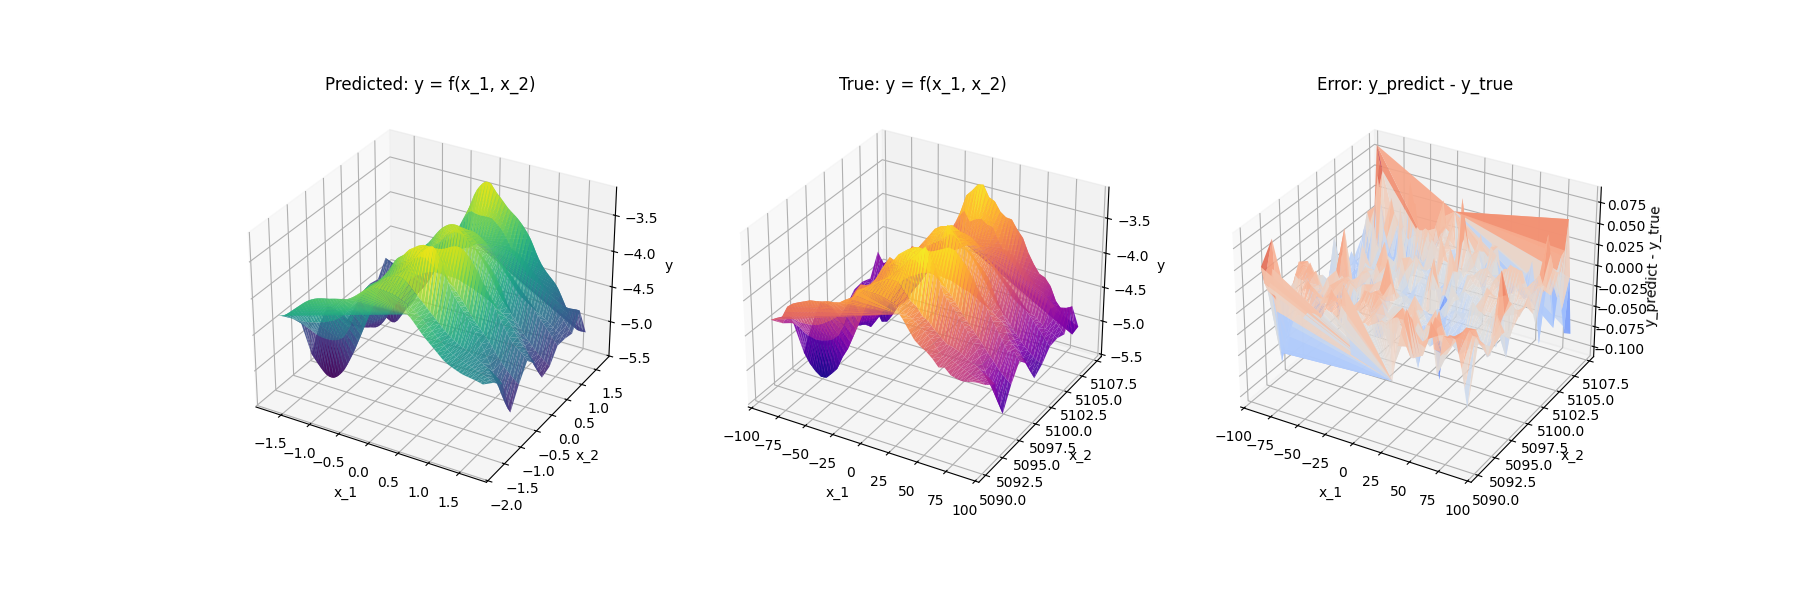

In [44]:
%matplotlib widget

fig = plt.figure(figsize=(18, 6))

# 1. График предсказаний модели (Y_pred)
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.plot_trisurf(X_ss[:, 0], X_ss[:, 1], Y_pred[:, 0], cmap='viridis', alpha=0.9)
ax1.set_xlabel("x_1")
ax1.set_ylabel("x_2")
ax1.set_zlabel("y")
ax1.set_title("Predicted: y = f(x_1, x_2)")

# 2. График исходных данных (Ground truth)
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_trisurf(file['In1'], file['In2'], file['Out1'], cmap='plasma', alpha=0.9)
ax2.set_xlabel("x_1")
ax2.set_ylabel("x_2")
ax2.set_zlabel("y")
ax2.set_title("True: y = f(x_1, x_2)")

# 3. График ошибки (Разница между предсказанием и истиной)
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
ax3.plot_trisurf(file['In1'], file['In2'], Y_pred[:, 0] - file['Out1'], cmap='coolwarm', alpha=0.9)
ax3.set_xlabel("x_1")
ax3.set_ylabel("x_2")
ax3.set_zlabel("y_predict - y_true")
ax3.set_title("Error: y_predict - y_true")

# Автоматическое выравнивание отступов, чтобы подписи не перекрывались
# plt.tight_layout()

plt.show()

In [31]:
print( sum( abs( Y_pred[:, 0] - file['Out1'] ) ) )
print( sum( abs( file['Out1'] ) ) )
print( sum( abs( Y_pred[:, 0] ) ) )

16.243465147399892
4269.24483
4266.983


#### Источники литературы

1. Нормализация - https://habr.com/en/articles/527334/
2. Нейронные сети и KAN - https://habr.com/en/articles/823388/ 
3. BackProp - https://ru.wikipedia.org/wiki/Метод_обратного_распространения_ошибки 
4. PyTorch 24h Tutorial - https://www.youtube.com/watch?v=Z_ikDlimN6A
5. 